---
#### 6-1. 비지도 학습 2 : 차원축소
- PCA, t-SNE
---

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

In [30]:
# pca example : 10개의 특성을 가진 데이터 
df = pd.read_csv('data/blobs.csv')
display(df.head())

# 정규화 -> 차원축소
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 

scaler = StandardScaler()
cols = df.columns[:-1]   # 마지막 컬럼(cluster) 제외
X_scaled = scaler.fit_transform(df[cols])

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# PCA 결과 : 설명분산 
variance_ratio = pca.explained_variance_ratio_
cum_variance = variance_ratio.cumsum()

df_variance = pd.DataFrame({
    'Principal_Component': [f'PC{i+1}' for i in range(len(variance_ratio))],
    'Explained_Variance_Ratio': variance_ratio,
    'Cumulative_Variance_Ratio': cum_variance
})

df_variance

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,cluster
0,2.850829,-6.834667,-3.989537,-1.510504,-1.418192,6.598430,-7.638539,-0.620259,0.041250,-9.345837,2
1,-2.178317,9.847815,2.646143,2.347226,-5.651958,-8.089751,-7.165755,7.742542,1.317288,4.105682,0
2,-1.708788,9.768577,5.828792,2.681474,-6.528179,-5.809959,-8.864849,6.441648,1.859233,3.416549,0
3,2.308991,-6.556074,-8.780863,9.968902,10.060086,6.465823,-3.457569,-8.150916,5.460151,-2.676146,3
4,-2.258705,9.360734,3.959854,2.205423,-6.586555,-7.594461,-6.972553,7.797356,0.830997,4.818005,0


,Principal_Component,Explained_Variance_Ratio,Cumulative_Variance_Ratio
0,PC1,0.546312,0.546312
1,PC2,0.214414,0.760726
2,PC3,0.115225,0.875951
3,PC4,0.078843,0.954794
4,PC5,0.021950,0.976744
5,PC6,0.011591,0.988335
6,PC7,0.003640,0.991975
7,PC8,0.003304,0.995279
8,PC9,0.002562,0.997842
9,PC10,0.002158,1.000000


#### 펭귄 데이터에 대한 PCA 실습 

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


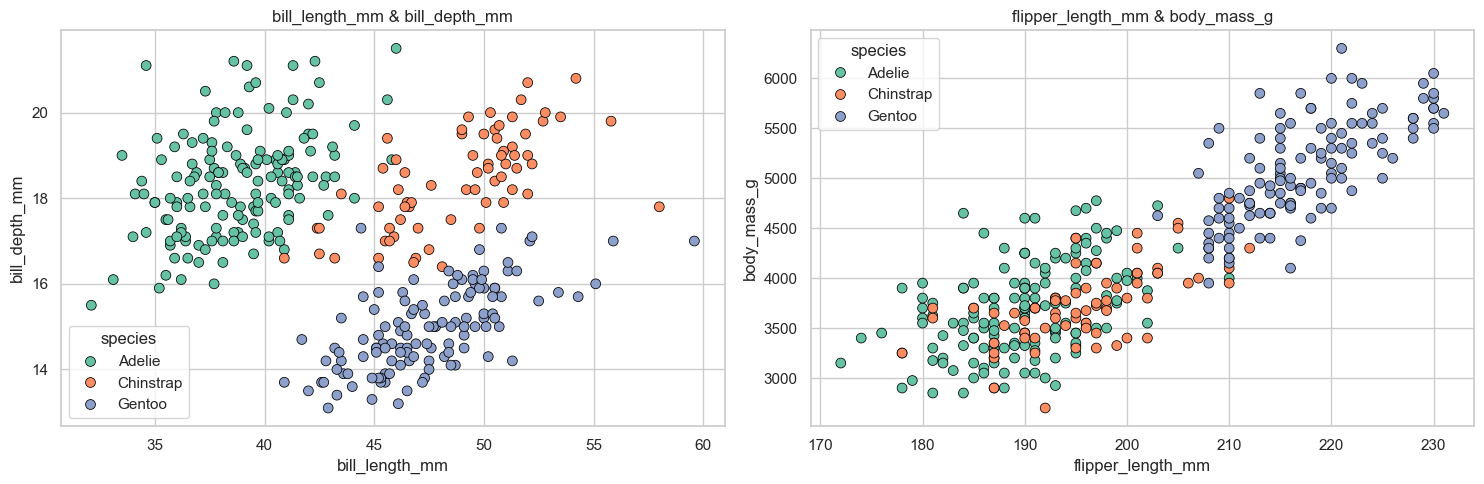

In [41]:
#################################################################
# 1. 데이터 로드 
#################################################################
penguins = sns.load_dataset('penguins')
display(penguins.head())

fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', 
                hue='species', palette='Set2', s=50, edgecolor='black',
                ax=axes[0]
                )

sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', 
                hue='species', palette='Set2', s=50, edgecolor='black',
                ax=axes[1]
                )

axes[0].set_title('bill_length_mm & bill_depth_mm')
axes[1].set_title('flipper_length_mm & body_mass_g')

plt.tight_layout()
plt.show()

In [42]:
#################################################################
# 1. 결측치제거, 수치형 컬럼 선택 
#################################################################
penguins = penguins.dropna()  
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins[features]

X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [43]:
#################################################################
# 2. 표준화, PCA 적용 
#################################################################
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

In [54]:
#################################################################
# 3. 결과 확인 
#################################################################
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2', 'PCA3', 'PCA4'])
df_pca['species'] = penguins['species']

variance_ratio = pca.explained_variance_ratio_
cum_variance = variance_ratio.cumsum()

df_variance = pd.DataFrame({
    'Principal_Component': [f'PC{i+1}' for i in range(len(variance_ratio))],
    'Explained_Variance_Ratio': variance_ratio,
    'Cumulative_Variance_Ratio': cum_variance
})

display(df_variance) 

,Principal_Component,Explained_Variance_Ratio,Cumulative_Variance_Ratio
0,PC1,0.686339,0.686339
1,PC2,0.194529,0.880868
2,PC3,0.092161,0.973029
3,PC4,0.026971,1.000000


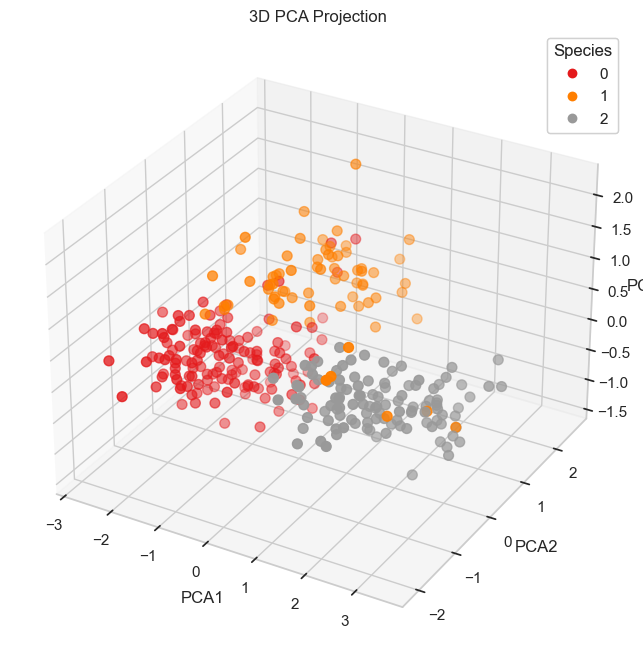

In [65]:
# 참고. 3D 시각화 
from mpl_toolkits.mplot3d import Axes3D

df_plot = df_pca.dropna(subset=['species']).copy()   # NaN 제거
# species를 category 코드로 변환 (색상용)
df_plot['species_code'] = df_plot['species'].astype('category').cat.codes
cmap = plt.cm.Set1  # 색상 맵

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_plot['PCA1'],
    df_plot['PCA2'],
    df_plot['PCA3'],
    c=df_plot['species_code'],
    cmap=cmap,
    s=50
)

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('3D PCA Projection')

# 범례 생성
legend1 = ax.legend(*scatter.legend_elements(), title="Species")
ax.add_artist(legend1)
plt.show()

---
#### t-SNE

,TSNE1,TSNE2,species
0,-12.945157,-0.676213,Adelie
1,-16.292671,-0.643321,Adelie
2,-19.112560,-1.531185,Adelie
3,-10.480476,-4.963211,Adelie
4,-6.572003,-2.582507,Adelie
...,...,...,...
328,29.874012,-8.232969,Gentoo
329,29.884426,-7.541728,Gentoo
330,35.103809,1.418659,Gentoo
331,28.999010,-5.206901,Gentoo


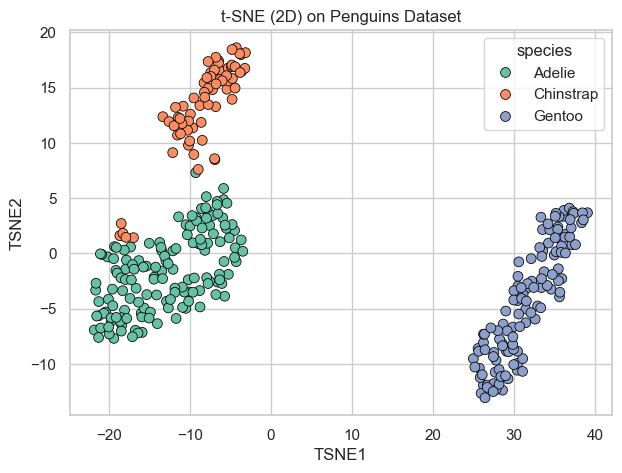

In [ ]:
penguins = sns.load_dataset('penguins')
penguins = penguins.dropna()

features = ['bill_length_mm', 'bill_depth_mm', 
            'flipper_length_mm', 'body_mass_g']

X = penguins[features]

# 표준화 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE 적용 (2차원)
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,      
    random_state=42,
    learning_rate='auto'
)

X_tsne = tsne.fit_transform(X_scaled)

# 결과 데이터프레임 : t-SNE에는 “설명분산(Explained Variance)”이나 “누적 기여도” 개념이 없음 
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['species'] = penguins['species'].values

# 시각화
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_tsne,
    x='TSNE1',
    y='TSNE2',
    hue='species',
    palette='Set2',
    s=50,
    edgecolor='black'
)

plt.title('t-SNE (2D)')
plt.show()

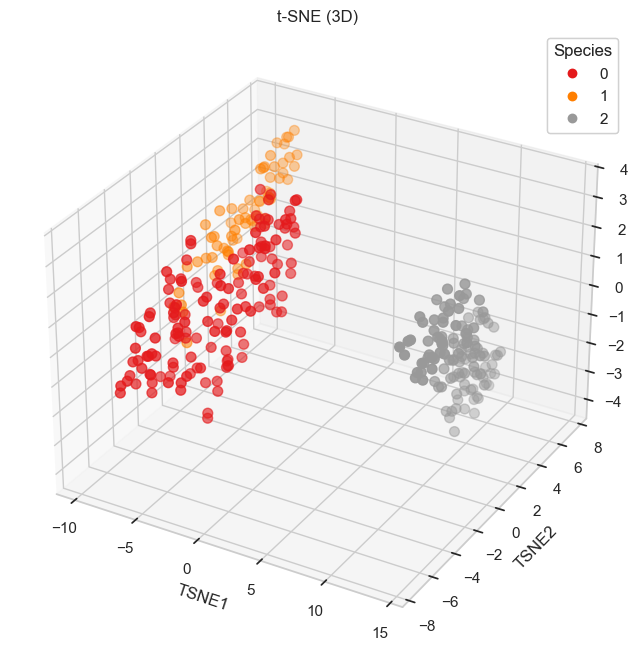

In [71]:
# t-SNE 적용 (3차원)
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=3,   
    perplexity=30,      
    random_state=42,
    learning_rate='auto'
)

X_tsne = tsne.fit_transform(X_scaled)

# 결과 데이터프레임 : t-SNE에는 “설명분산(Explained Variance)”이나 “누적 기여도” 개념이 없음 
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2', 'TSNE3'])
df_tsne['species'] = penguins['species'].values

# 시각화 (3D)
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# species를 숫자로 변환 (색상 매핑용)
df_tsne['species_code'] = df_tsne['species'].astype('category').cat.codes

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_tsne['TSNE1'],
    df_tsne['TSNE2'],
    df_tsne['TSNE3'],
    c=df_tsne['species_code'],
    cmap='Set1',
    s=50
)

ax.set_xlabel('TSNE1')
ax.set_ylabel('TSNE2')
ax.set_zlabel('TSNE3')
ax.set_title('t-SNE (3D)')

legend1 = ax.legend(*scatter.legend_elements(), title="Species")
ax.add_artist(legend1)

plt.show()